**Navigation:**  
[← Interventions](07_interventions.ipynb) | [Superspreader Party Crawl](05_superspreader_party_crawl.ipynb) | [Rt Decomposition](06_rt_wells_riley_decomposition.ipynb)

# Timed Interventions: Component-Level and Structured-Model Views

This notebook shows timed interventions in two complementary ways:
1. Component schedule affecting $c_t$ and Wells-Riley terms, yielding $R_t(t)$.
2. Time-bounded matrix interventions in a superspreader-party-crawl system.

In [17]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))

if "epi" in globals():
    reloader = getattr(epi, "reload_package_modules", None)
    if callable(reloader):
        epi = reloader("epi_structure")
    else:
        print("epi_structure already loaded; restart kernel to pick up package changes.")
        import epi_structure as epi
else:
    import epi_structure as epi

from epi_structure import (
    DiseaseParameters,
    Scenario,
    SimulationParameters,
    StructuredEpidemicModel,
    compose_intervention_plan,
    intervene_bridge_links,
    intervene_within_groups,
    trajectory_to_df,
)

plt.style.use('seaborn-v0_8-darkgrid')

epi_structure already loaded; restart kernel to pick up package changes.


In [18]:
def wells_riley_probability(
    infectious_people: float,
    quanta_emission_rate: float,
    breathing_rate: float,
    exposure_hours: float,
    clean_air_rate: float,
    mask_exhale_eff: float = 0.0,
    mask_inhale_eff: float = 0.0,
    mixing_factor: float = 1.0,
) -> tuple[float, float]:
    phi_mask = (1.0 - mask_exhale_eff) * (1.0 - mask_inhale_eff)
    effective_denominator = max(clean_air_rate * mixing_factor, 1e-12)
    dose = infectious_people * quanta_emission_rate * breathing_rate * exposure_hours * phi_mask / effective_denominator
    p_inf = 1.0 - np.exp(-dose)
    return float(p_inf), float(dose)


def rt_from_contact_probability(
    contact_rate_per_day: float,
    infectious_duration_days: float,
    p_infection_per_contact: float,
    susceptible_fraction: float,
) -> float:
    return float(contact_rate_per_day * infectious_duration_days * p_infection_per_contact * susceptible_fraction)


def pop(df_in: pd.DataFrame, name: str) -> pd.DataFrame:
    return df_in[df_in['population'] == name].copy()

## 1) Component-Level Timed Policy Schedule

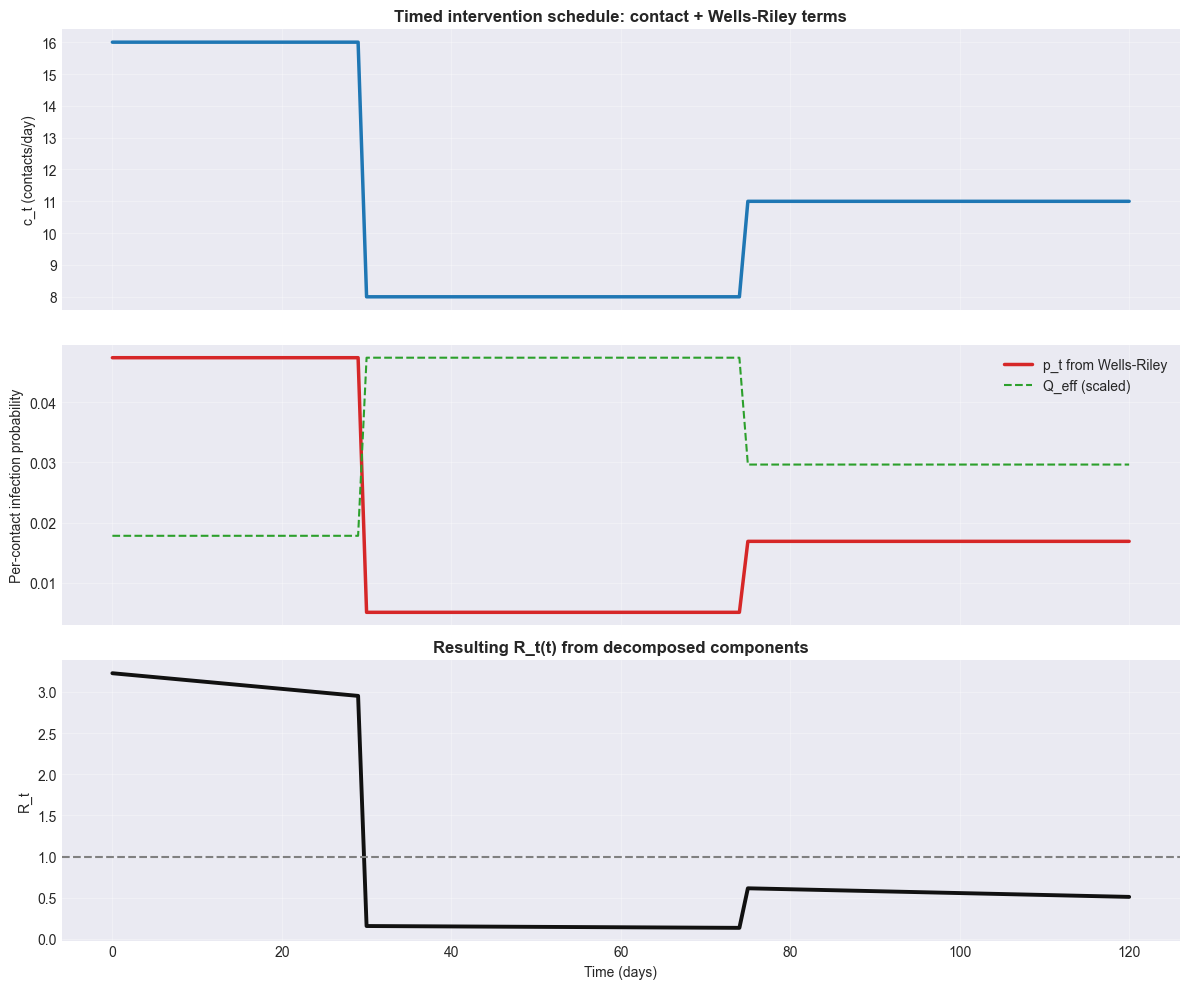

In [8]:
t_days = np.arange(0.0, 121.0, 1.0)

contact_t = np.where(t_days < 30, 16.0, np.where(t_days < 75, 8.0, 11.0))
Qeff_t = np.where(t_days < 30, 1200.0, np.where(t_days < 75, 3200.0, 2000.0))
mask_exhale_t = np.where(t_days < 30, 0.20, np.where(t_days < 75, 0.60, 0.40))
mask_inhale_t = np.where(t_days < 30, 0.10, np.where(t_days < 75, 0.50, 0.30))
Sfrac_t = np.clip(0.85 - 0.0025 * t_days, 0.55, 0.85)

p_t = np.zeros_like(t_days, dtype=float)
Rt_t = np.zeros_like(t_days, dtype=float)

for idx, _ in enumerate(t_days):
    p_now, _dose = wells_riley_probability(
        infectious_people=1.0,
        quanta_emission_rate=45.0,
        breathing_rate=0.60,
        exposure_hours=3.0,
        clean_air_rate=float(Qeff_t[idx]),
        mask_exhale_eff=float(mask_exhale_t[idx]),
        mask_inhale_eff=float(mask_inhale_t[idx]),
        mixing_factor=1.0,
    )
    p_t[idx] = p_now
    Rt_t[idx] = rt_from_contact_probability(float(contact_t[idx]), 5.0, p_now, float(Sfrac_t[idx]))

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
axes[0].plot(t_days, contact_t, color='#1f77b4', linewidth=2.5)
axes[0].set_ylabel('c_t (contacts/day)')
axes[0].set_title('Timed intervention schedule: contact + Wells-Riley terms', fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_days, p_t, color='#d62728', linewidth=2.5, label='p_t from Wells-Riley')
axes[1].plot(t_days, Qeff_t / Qeff_t.max() * p_t.max(), color='#2ca02c', linewidth=1.5, linestyle='--', label='Q_eff (scaled)')
axes[1].set_ylabel('Per-contact infection probability')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

axes[2].plot(t_days, Rt_t, color='#111111', linewidth=2.8)
axes[2].axhline(1.0, color='gray', linestyle='--', linewidth=1.5)
axes[2].set_xlabel('Time (days)')
axes[2].set_ylabel('R_t')
axes[2].set_title('Resulting R_t(t) from decomposed components', fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2) Structured-Model Timed Interventions in Party Crawl

In [19]:
crawl_disease = DiseaseParameters(infectious_period=6.0, latent_period=2.5)
crawl_sim = SimulationParameters(time_step=0.1, duration=180.0, output_stride=10)

crawl_seed = Scenario(
    name='party_crawl_seed',
    description='Seed scenario for timed intervention crawl runs',
    populations=[],
    contact_matrix=[],
    population_names=[],
    simulation=crawl_sim,
    intervention_plan=None,
)

crawl_scenario = (
    Scenario.builder(base=crawl_seed, name='party_crawl_timed_base')
    .disease(crawl_disease)
    .population('general', size=15_000, beta=0.0, initial_infected=8)
    .population('party_a', size=300, beta=0.0, initial_infected=0)
    .population('party_b', size=300, beta=0.0, initial_infected=0)
    # row=recipient, col=source
    .transition('general', 'general', 0.0000065)
    .transition('general', 'party_a', 0.0000300)
    .transition('general', 'party_b', 0.0000300)
    .transition('party_a', 'general', 0.0000040)
    .transition('party_a', 'party_a', 0.0015000)
    .transition('party_a', 'party_b', 0.0002000)
    .transition('party_b', 'general', 0.0000040)
    .transition('party_b', 'party_a', 0.0002000)
    .transition('party_b', 'party_b', 0.0015000)
    .build()
)

crawl_populations = crawl_scenario.populations
C_crawl = np.array(crawl_scenario.contact_matrix, dtype=float)

baseline_traj = StructuredEpidemicModel(
    populations=crawl_populations,
    contact_matrix=C_crawl.tolist(),
    simulation=crawl_sim,
    intervention_plan=None,
).simulate()
df_baseline = trajectory_to_df(baseline_traj)
g_baseline = pop(df_baseline, 'general')

timed_plan = compose_intervention_plan(
    intervene_within_groups(['party_a', 'party_b'], scale=0.45, start_time=35.0, end_time=120.0),
    intervene_bridge_links([('general', 'party_a'), ('general', 'party_b'), ('party_a', 'party_b')], scale=0.35, start_time=40.0, end_time=120.0, symmetric=True),
)

timed_traj = StructuredEpidemicModel(
    populations=crawl_populations,
    contact_matrix=C_crawl.tolist(),
    simulation=crawl_sim,
    intervention_plan=timed_plan,
).simulate()
df_timed = trajectory_to_df(timed_traj)
g_timed = pop(df_timed, 'general')

AttributeError: type object 'Scenario' has no attribute 'builder'

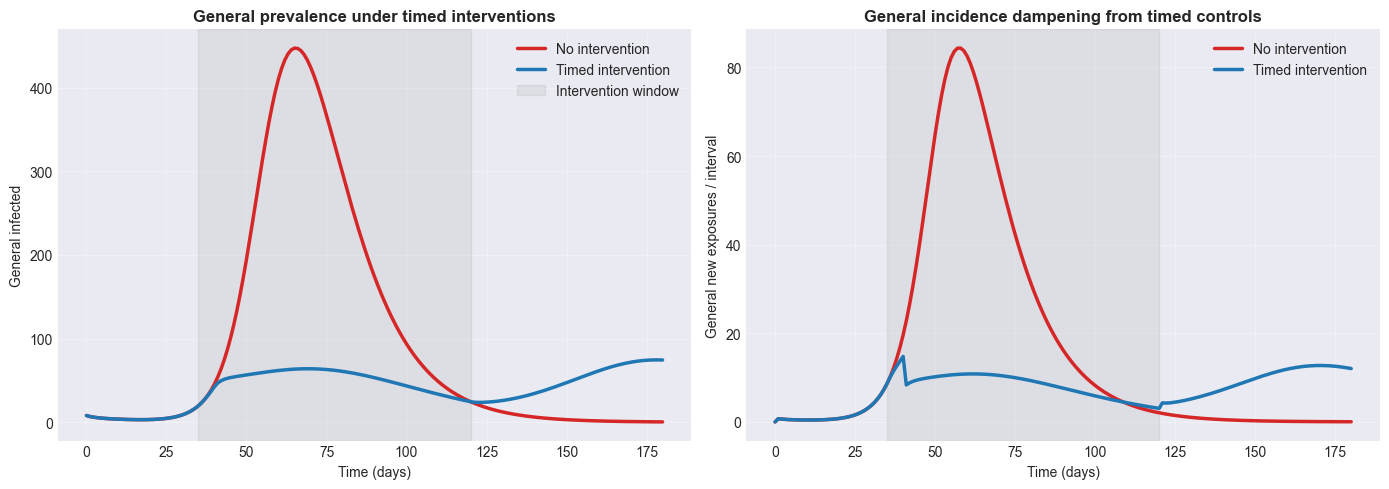

Timed intervention impact (general population):
  Peak I, no intervention: 447.4
  Peak I, timed intervention: 74.5
  Cumulative infected (N-S at end), no intervention: 2928.6
  Cumulative infected (N-S at end), timed intervention: 1330.9


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

axes[0].plot(g_baseline['time'], g_baseline['I'], linewidth=2.5, color='#d62728', label='No intervention')
axes[0].plot(g_timed['time'], g_timed['I'], linewidth=2.5, color='#1f77b4', label='Timed intervention')
axes[0].axvspan(35.0, 120.0, alpha=0.12, color='gray', label='Intervention window')
axes[0].set_xlabel('Time (days)')
axes[0].set_ylabel('General infected')
axes[0].set_title('General prevalence under timed interventions', fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper right')

axes[1].plot(g_baseline['time'], g_baseline['new_exposed_interval'], linewidth=2.5, color='#d62728', label='No intervention')
axes[1].plot(g_timed['time'], g_timed['new_exposed_interval'], linewidth=2.5, color='#1f77b4', label='Timed intervention')
axes[1].axvspan(35.0, 120.0, alpha=0.12, color='gray')
axes[1].set_xlabel('Time (days)')
axes[1].set_ylabel('General new exposures / interval')
axes[1].set_title('General incidence dampening from timed controls', fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

print('Timed intervention impact (general population):')
print(f"  Peak I, no intervention: {g_baseline['I'].max():.1f}")
print(f"  Peak I, timed intervention: {g_timed['I'].max():.1f}")
print(f"  Cumulative infected (N-S at end), no intervention: {g_baseline['N'].iloc[-1] - g_baseline['S'].iloc[-1]:.1f}")
print(f"  Cumulative infected (N-S at end), timed intervention: {g_timed['N'].iloc[-1] - g_timed['S'].iloc[-1]:.1f}")